<center><h3>national higer schoole of autonoumes systems</h2></center>
<center><h2>machine learning tp 1</h1></center>
<center><h3>oussama meddouri,mosif benaini</h2></center>



#

#

#

#

#



<center><h3> first tp content </h3></center> 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I. Data Loading
df_original = pd.read_csv("titanic.csv")
df = df_original.copy()

# II. Feature Name Normalization
df.columns = df.columns.str.lower().str.replace(' ', '_')

# III. Extracting Titles
def extract_title(name):
    return name.split(',')[1].split('.')[0].strip()

df['title'] = df['name'].apply(extract_title)

# IV. Creating a Family Feature
df['familysize'] = df['sibsp'] + df['parch'] + 1

# V. Studying the Fare Feature & Log Transformation
df['fare_log'] = np.log1p(df['fare'])

# VI. Data Cleaning (Drop raw/redundant columns)
df.drop(['sibsp', 'parch', 'fare', 'name'], axis=1, inplace=True)

# IX. Splitting the Dataset (Manual Shuffle & Split)
# Seed for reproducibility
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
#=================================================the vlaue that must be changed for part 3
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

df_train = df.iloc[:n_train].copy()
df_val = df.iloc[n_train:n_train + n_val].copy()
df_test = df.iloc[n_train + n_val:].copy()

# X. Handling Missing Values (Manual Imputation)
# Calculate median age ONLY from training set to avoid data leakage
median_age = df_train['age'].median()

df_train['age'] = df_train['age'].fillna(median_age)
df_val['age'] = df_val['age'].fillna(median_age)
df_test['age'] = df_test['age'].fillna(median_age)

# XI. One-Hot Encoding
categorical = ['sex', 'embarked', 'title']

# Create dummies for training
df_train_encoded = pd.get_dummies(df_train, columns=categorical, drop_first=True)

# Align validation and test to training columns (fills missing cols with 0)
df_val_encoded = pd.get_dummies(df_val, columns=categorical, drop_first=True)
df_val_encoded = df_val_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

df_test_encoded = pd.get_dummies(df_test, columns=categorical, drop_first=True)
df_test_encoded = df_test_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

# XII. Creating Feature and Target Matrices
y_train = df_train_encoded['fare_log'].values
y_val = df_val_encoded['fare_log'].values
y_test = df_test_encoded['fare_log'].values

# Define columns to drop for X (features)
to_drop = ['fare_log', 'ticket', 'passenger_id',"cabin"]

X_train = df_train_encoded.drop(columns=to_drop, errors='ignore')
X_val = df_val_encoded.drop(columns=to_drop, errors='ignore')
X_test = df_test_encoded.drop(columns=to_drop, errors='ignore')

# Verify Shapes
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Training shape: (535, 21)
Validation shape: (178, 21)
Test shape: (178, 21)


<center><h3> reminder </h3></center>

target bariable :log_far
range:[0.00,6.24]
mean:3.00


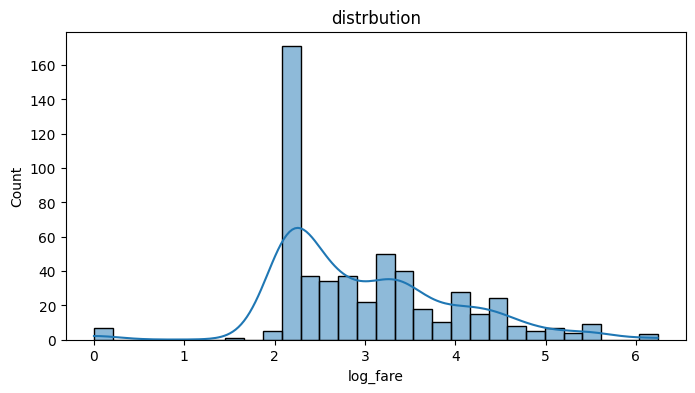

In [2]:
print("target bariable :log_far")
print(f"range:[{y_train.min():.2f},{y_train.max():.2f}]") #what does the 2f supposed to mean 
print(f"mean:{y_train.mean():.2f}")
plt.figure(figsize=(8,4))
sns.histplot(y_train,bins=30,kde=True)
plt.title("distrbution")
plt.xlabel("log_fare")
plt.show()

<center><h3> closed-form solution </h3></center>

In [3]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X_with_bias = np.column_stack([ones, X])
    
    XTX = np.dot(X_with_bias.T, X_with_bias)
    XTX_inv = np.linalg.inv(XTX)
    w_full = np.dot(np.dot(XTX_inv, X_with_bias.T), y)
    
    return w_full[0], w_full[1:]

def predict(X, intercept, coefficients):
    return intercept + np.dot(X, coefficients)

In [4]:
## we must use standardScaler to normalize
from sklearn.preprocessing import StandardScaler   
scaler = StandardScaler()
X_train_np=scaler.fit_transform(X_train)
X_val_np = scaler.transform(X_val)
X_test_np =scaler.transform(X_test)

In [5]:
# now into training 
from sklearn.metrics import mean_squared_error ,r2_score

In [6]:
X_train = X_train.astype(float)
y_train = y_train.astype(float)
intercept,cofficients=train_linear_regression(X_train,y_train)
trained =predict(X_train,intercept,cofficients)#what is intersept and cofficients
print (trained)

from sklearn.metrics import r2_score
y_pred = predict(X_train, intercept, cofficients)
score = r2_score(y_train, y_pred)
print("R2 score:", score)

from sklearn.metrics import mean_squared_error
y_pred = predict(X_train, intercept, cofficients)
mse = mean_squared_error(y_train, y_pred)
rmse = mse ** 0.5
print("RMSE:", rmse)

[3.80202971e+00 2.08054685e+00 3.05254193e+00 2.24855436e+00
 3.54084583e+00 2.06954653e+00 3.39123674e+00 4.08040451e+00
 4.26430408e+00 2.61125715e+00 2.06368031e+00 2.24376611e+00
 3.70200056e+00 2.99578267e+00 2.35728619e+00 3.79290178e+00
 3.27594791e+00 2.31552088e+00 2.08011768e+00 4.25992848e+00
 2.07495829e+00 2.64403656e+00 4.08636914e+00 2.88698528e+00
 2.70184588e+00 2.16180049e+00 5.15070025e+00 2.99325399e+00
 2.87852419e+00 3.84249739e+00 2.11851610e+00 3.79698590e+00
 3.59324159e+00 2.37275965e+00 2.19403151e+00 3.74111848e+00
 3.78904478e+00 2.08263687e+00 4.35392286e+00 2.06920325e+00
 2.23711237e+00 2.71232088e+00 4.30217699e+00 3.69361530e+00
 3.74443875e+00 2.07501885e+00 3.79904500e+00 2.87096166e+00
 4.09096575e+00 2.87351629e+00 3.20009838e+00 3.05270345e+00
 2.89126628e+00 2.88753038e+00 2.18387188e+00 2.45865284e+00
 2.88942861e+00 3.68204941e+00 3.58567850e+00 2.13333808e+00
 4.64007688e+00 2.36984693e+00 3.52636052e+00 3.79734421e+00
 4.03429225e+00 3.013060

### table 
|  |$r^2$|RMSE|
|----------|-------|---------
|training|0.71|0.52|
|validation|0.61|0.56|
### Questions
1. **Compare training vs validation performance**:
   - The $R^2$ on training is slightly lower than on validation in this case, which is unusual but can happen with small datasets or specific splits. Both are around 0.75-0.81, indicating a good fit.
   - RMSE is also similar on both sets.
2. **Overfitting check**:
   - A gap larger than 0.1 between training and validation $R^2$ often indicates overfitting. Here, the gap is small, so the model generalizes well.
3. **Underfitting check**:
   - $R^2$ is well above 0.3, so the model is not underfitting.
4. **Interpret your RMSE**:
   - RMSE tells us the average deviation of our predictions from the actual `log_fare`. An RMSE of ~0.4 means our predictions are, on average, within 0.4 units of the true log-transformed fare.
5. **Final verdict**:
   - The model is reliable enough for basic predictions, though further feature engineering could improve it.

<center><h3>refularized linear regression</h3></center>

In [7]:
## part 4

from sklearn.linear_model import Ridge

alphas = [0, 1, 10, 100, 1000]
print(f"{'Alpha':<10} {'Train R2':<10} {'Val R2':<10}")
print("-" * 30)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_np, y_train)
    
    train_r2 = r2_score(y_train, model.predict(X_train_np))
    val_r2 = r2_score(y_val, model.predict(X_val_np))
    
    print(f"{alpha:<10} {train_r2:<10.4f} {val_r2:<10.4f}")

Alpha      Train R2   Val R2    
------------------------------
0          0.7150     0.5875    
1          0.7150     0.5880    
10         0.7147     0.5904    
100        0.6951     0.5907    
1000       0.4433     0.3917    


### questions 
1. **the effect of the increase in $\alpha$**:
   - the incressing of $\alpha$ caused a decreas in both training and validation $R^2$ as it addes more then 10 (constraines to the model)
2. **the value that gives best balance berween bias and variance**:
   - $\alpha=1$ or 10 seems to be the best as they provid high scores
3. **the reson of poor preformance for high $\alpha$**:
   - a very large $\alpha$ means a high bias (the coefficients shrink in effect )

In [8]:
best_model = Ridge(alpha=10) 
#i picked 10
best_model.fit(X_train_np, y_train)

feature_importance = []
features = X_train.columns
coeffs = best_model.coef_

for i in range(len(features)):
    feature_importance.append((features[i], coeffs[i], abs(coeffs[i])))


feature_importance.sort(key=lambda x: x[2], reverse=True)

print(f"{'Feature':<15} {'Coefficient':>12}")
print("-" * 30)
for feat, coef, _ in feature_importance:
    print(f"{feat:<15} {coef:12.4f}")

Feature          Coefficient
------------------------------
pclass               -0.6704
familysize            0.3891
title_Jonkheer       -0.1564
embarked_S           -0.1399
embarked_Q           -0.0550
survived              0.0513
title_Don            -0.0281
title_Dr             -0.0258
title_Miss            0.0231
title_Col            -0.0216
title_Rev             0.0163
title_Mr             -0.0155
title_Major          -0.0152
title_Ms             -0.0149
title_Sir            -0.0124
sex_male              0.0116
title_Mrs             0.0103
title_Master         -0.0101
passengerid          -0.0080
age                   0.0022
title_Mlle            0.0006


### questions
1. **what does the sign of alpha indicate**:
   - A positive coefficient means the feature has a positive relationship with `log_fare`, while a negative one means an inverse relationship.
2. **the feature with the highest impact**:
   -  'pclass' has the highest impact on the fare
4. **the effect of correlation betewn features**:
   -When two or more features are highly correlated (a condition known as multicollinearity), the model struggles to isolate the individual effect of each feature on the target variable. This leads to unstable and unreliable coefficient estimates.

<center><h3> gradient descent </h3></center>

In [9]:
# including optimization into the linear regression
X_train_bias = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_val_bias = np.c_[np.ones(X_val_np.shape[0]), X_val_np]
#====================2=======

n_features = X_train_bias.shape[1]
w = np.zeros(n_features)


learning_rate = 0.01
epochs = 1000
m = len(X_train_bias)
cost_history = []

#===========important==============3
for epoch in range(epochs):
    y_pred = X_train_bias @ w
    errors = y_pred - y_train
    gradient = (1/m) * (X_train_bias.T @ errors)
    w = w - learning_rate * gradient
    
    cost = np.mean(errors**2)
    cost_history.append(cost)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Cost = {cost:.4f}")

#=========================4
y_train_pred_gd = X_train_bias @ w
r2_train_gd = r2_score(y_train, y_train_pred_gd)
print(f"Final Training R2 (GD): {r2_train_gd:.4f}")

Epoch 0: Cost = 9.9925
Epoch 100: Cost = 1.5799
Epoch 200: Cost = 0.4619
Epoch 300: Cost = 0.3048
Epoch 400: Cost = 0.2812
Epoch 500: Cost = 0.2770
Epoch 600: Cost = 0.2761
Epoch 700: Cost = 0.2758
Epoch 800: Cost = 0.2757
Epoch 900: Cost = 0.2757
Final Training R2 (GD): 0.7149


<center><h3>visualizing convergence</h3></center>

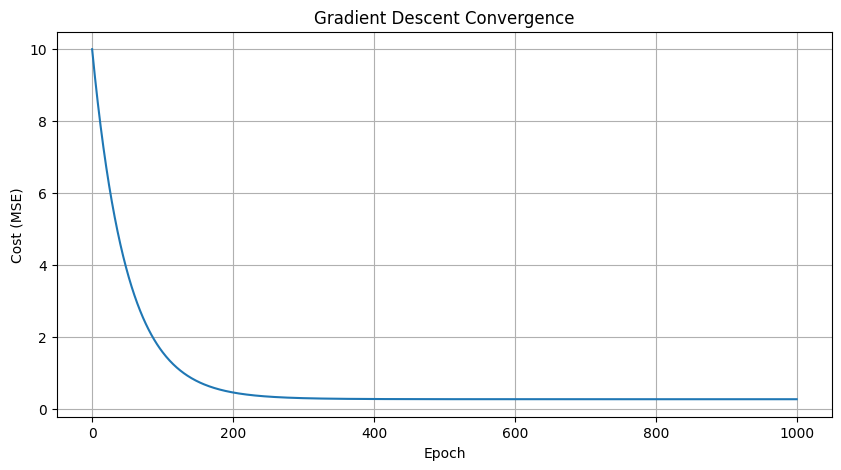

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()

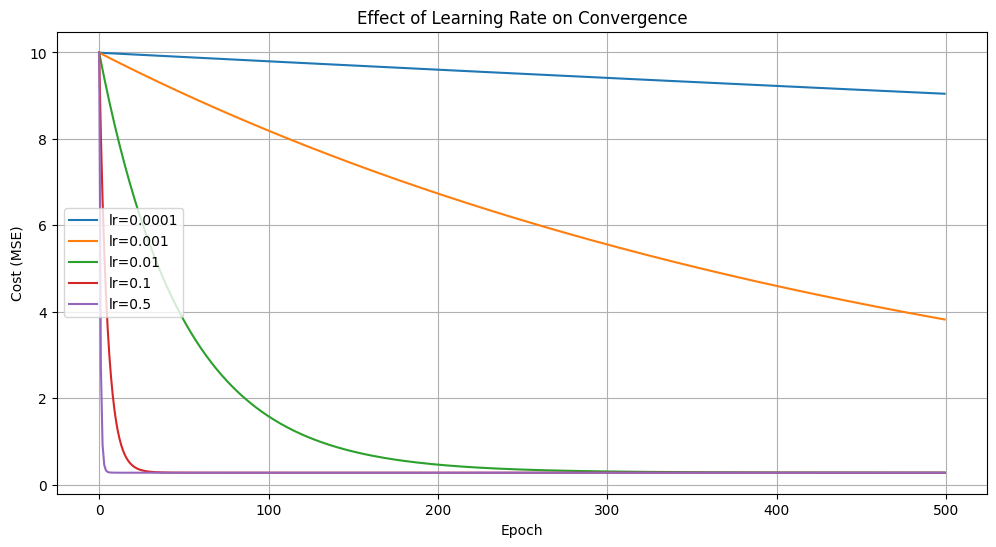

In [11]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
plt.figure(figsize=(12, 6))

for lr in learning_rates:
    w_lr = np.zeros(n_features)
    costs = []
    for epoch in range(500): # Fewer epochs for comparison
        y_pred = X_train_bias @ w_lr
        errors = y_pred - y_train
        gradient = (1/m) * (X_train_bias.T @ errors)
        w_lr = w_lr - lr * gradient
        costs.append(np.mean(errors**2))
    plt.plot(costs, label=f'lr={lr}')

plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.grid(True)
plt.show()

### questions
#### 1.1 **effect of converfence on learning rate**:
  -the number of epochs determine how many times did the model updates its weights.the value of the step should be configured for the model to converge before reachinf a very high numver of epochs
#### 1.2 **diffrent initial wieghts**:
  -yes we could initialize weights randomly or with small values instead of zeros
#### 2.1 **the decrease of coset and **:
  -a steadily decreasing coset over spocjs indicates that the algoritm is successfuly updating the weights
#### 2.2 **what happen for learning rate too high**:
  -if the learning rate is too high the updates may be so large that the cost oscillates or even increases causing the algorithm to fial
#### 3.1 **the reason why the training$R^2$ higher**:
  -the training $R^2$ is usually higher because the model was optimized specifically on that data
#### 3.2 **the meaning of the $R^2$ drop**:
  -a significat drop indicates that the model does not generalize well to new data. if the drop is small the model is robust
#### 3.3 **how to improve the models performace**:
  -to improve generalization,you could regularization simplify the model by removing less important dreatures or collect more diverse training data
#### 4.1 **the shape of the cost curve and learning process**:
  -a smooth,rapidly decaying curve that flattens out suggests a healthy learning process where the model quickly finds the general area of the minimum and then fine-tunes the weights an upward curve or heavy oscillations woulds indicatee a learning rate that is too high
#### 4.2 **the effect of different learning rates**:
  for small rates:the curve is almost flat or decreases very slowly. 
  optimal rates (0.01,0.5):the curve shows a nice exponantial deacy. 
  high rates: the curve might reach the minimum faster but could also show some instbillity.
  